# C-BIoU tracking experiment

Same setup as `04_ocsort_tracking.ipynb`, swapping the `trackers` package's `OCSORTTracker` for its `CBIoUTracker`, to compare Cascaded-Buffered IoU matching (Yang et al., WACV 2023) against OC-SORT's observation-centric approach on the same clip.

C-BIoU has no motion model beyond buffered-box overlap: it expands boxes by a proportional margin (`buffer_ratio_first` then the larger `buffer_ratio_second`) and matches in two cascaded passes instead of relying on a Kalman velocity estimate. Like OC-SORT, unresolved detections surface as `tracker_id == -1` — but the meaning differs: OC-SORT uses `-1` for tracks that haven't yet hit `minimum_consecutive_frames`, while C-BIoU uses it for low-confidence detections left over after both association passes.

This only reads from `orc_model` (`ClipDataset`, `Clip`, `Detector`) — the video decoding, frame sampling, and tracking loop below are playground-only glue, not promoted into `src/`.

In [1]:
# --- imports
import warnings
from pathlib import Path

import cv2
import numpy as np
import supervision as sv
from trackers import CBIoUTracker

from orc_model.data import ClipDataset
from orc_model.components.detector import Detector

# unrelated internal deprecation noise from `trackers` itself (a `target=None`
# proxy warning raised on import), not anything about our usage
warnings.filterwarnings("ignore", category=FutureWarning, module="trackers")

# --- config
CLIP_NAME = "IMG_2081"
WEIGHTS_PATH = Path("../weights/rf-detr-seg-2xl-v1.onnx")
CONFIDENCE_THRESHOLD = 0.60
TARGET_FPS = 5
OUTPUT_VIDEO_PATH = Path("../artifacts") / f"{CLIP_NAME}_cbiou_tracked_{TARGET_FPS}fps.mp4"

## Load the clip

`Clip` (from `orc_model.data`) already knows the raw video's path, native fps, frame count, and resolution — reuse that instead of re-deriving it.

In [2]:
dataset = ClipDataset.from_data_dir()
clip = dataset.get_clip(CLIP_NAME)

print(f"video: {clip.video_path}")
print(f"native fps: {clip.fps}, frame_count: {clip.frame_count}, resolution: {clip.resolution}")

video: /Users/constantijn/Documents/eTHi.Link/dev/MVP-OKcamera/model/data/IMG_2081/video/IMG_2081.mp4
native fps: 30.0, frame_count: 1859, resolution: (1920, 1080)


## Sample frames at 5 fps

The annotated `images/` frames per clip are a sparse hand-picked subset (too sparse to track through) — for tracking we need a dense, evenly-spaced sample straight from the video, decoded sequentially so we don't rely on potentially-inaccurate keyframe seeking.

In [3]:
def sample_frame_indices(native_fps: float, frame_count: int, target_fps: float) -> list[int]:
    """Evenly-spaced frame indices approximating `target_fps` given the video's native fps."""
    step = max(round(native_fps / target_fps), 1)
    return list(range(0, frame_count, step))


def read_frames(video_path: Path, frame_indices: list[int]) -> list[np.ndarray]:
    """Sequential decode + pick, rather than repeated `cap.set(...)` seeks."""
    wanted = set(frame_indices)
    cap = cv2.VideoCapture(str(video_path))
    frames_by_index = {}
    index = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if index in wanted:
            frames_by_index[index] = frame
        index += 1
    cap.release()
    return [frames_by_index[i] for i in frame_indices if i in frames_by_index]


frame_indices = sample_frame_indices(clip.fps, clip.frame_count, TARGET_FPS)
frames = read_frames(clip.video_path, frame_indices)

print(f"sampling every {max(round(clip.fps / TARGET_FPS), 1)} native frames -> {len(frames)} frames at ~{TARGET_FPS} fps")

sampling every 6 native frames -> 310 frames at ~5 fps


## Detect + track

Run the RF-DETR `Detector` on each sampled frame, then feed its `sv.Detections` into `trackers`' `CBIoUTracker.update` in temporal order so tracks are matched frame-to-frame. Masks and boxes are colored by track ID so the same instrument keeps the same color across frames.

In [4]:
detector = Detector(WEIGHTS_PATH, confidence_threshold=CONFIDENCE_THRESHOLD)
tracker = CBIoUTracker(frame_rate=TARGET_FPS)

mask_annotator = sv.MaskAnnotator(opacity=0.5, color_lookup=sv.ColorLookup.TRACK)
box_annotator = sv.BoxAnnotator(color_lookup=sv.ColorLookup.TRACK)
label_annotator = sv.LabelAnnotator(color_lookup=sv.ColorLookup.TRACK)

annotated_frames = []
track_ids_per_frame = []  # per-frame set of active track ids, for the summary below

for image in frames:
    detections = detector.predict(image)
    tracked = tracker.update(detections)

    labels = [f"#{tracker_id}" for tracker_id in tracked.tracker_id]
    annotated = image.copy()
    annotated = mask_annotator.annotate(annotated, tracked)
    annotated = box_annotator.annotate(annotated, tracked)
    annotated = label_annotator.annotate(annotated, tracked, labels=labels)

    annotated_frames.append(annotated)
    track_ids_per_frame.append(set(tracked.tracker_id.tolist()))

print(f"tracked {len(annotated_frames)} frames")

tracked 310 frames


## Track persistence over time

In [5]:
all_track_ids = sorted(set().union(*track_ids_per_frame)) if track_ids_per_frame else []
print(f"{len(all_track_ids)} unique track ids observed over {len(frames)} sampled frames\n")

for track_id in all_track_ids:
    frame_hits = sum(track_id in ids for ids in track_ids_per_frame)
    print(f"  track #{track_id}: present in {frame_hits}/{len(frames)} sampled frames")

19 unique track ids observed over 310 sampled frames

  track #-1: present in 25/310 sampled frames
  track #0: present in 224/310 sampled frames
  track #1: present in 280/310 sampled frames
  track #2: present in 1/310 sampled frames
  track #3: present in 241/310 sampled frames
  track #4: present in 211/310 sampled frames
  track #5: present in 193/310 sampled frames
  track #6: present in 169/310 sampled frames
  track #7: present in 143/310 sampled frames
  track #8: present in 80/310 sampled frames
  track #9: present in 109/310 sampled frames
  track #10: present in 84/310 sampled frames
  track #11: present in 71/310 sampled frames
  track #12: present in 2/310 sampled frames
  track #13: present in 54/310 sampled frames
  track #14: present in 51/310 sampled frames
  track #15: present in 2/310 sampled frames
  track #16: present in 30/310 sampled frames
  track #17: present in 29/310 sampled frames


## Visualize a few sampled frames

Masks, boxes, and labels are colored by track ID (`ColorLookup.TRACK`), so the same instrument keeps the same color across frames — this is the actual instance segmentation output, not just a box.

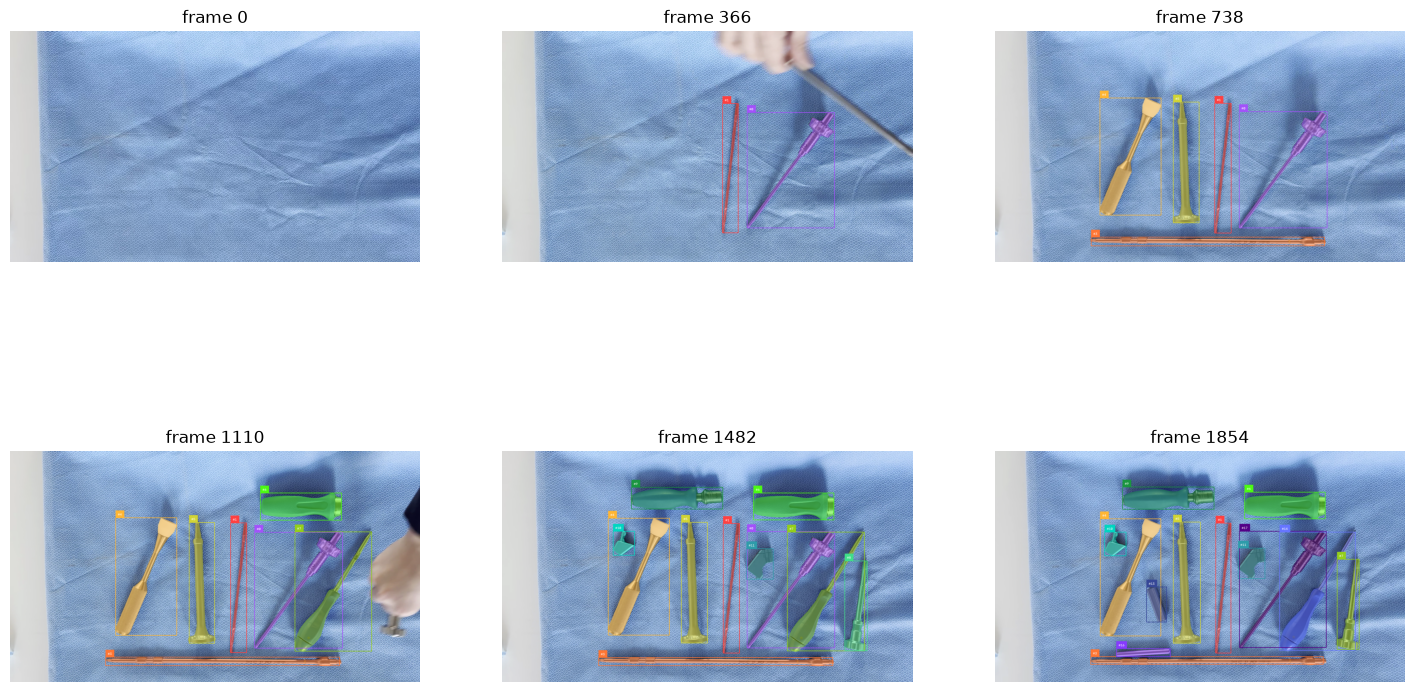

In [6]:
preview_positions = np.linspace(0, len(annotated_frames) - 1, num=min(6, len(annotated_frames)), dtype=int)
preview_frames = [annotated_frames[i] for i in preview_positions]
preview_titles = [f"frame {frame_indices[i]}" for i in preview_positions]

sv.plot_images_grid(preview_frames, grid_size=(2, 3), titles=preview_titles, size=(18, 10))

## Save the annotated result as a video

Written at `TARGET_FPS` (5) since that's the rate frames were sampled and tracked at — playing it back at the native fps would fast-forward through the tracking result.

In [7]:
OUTPUT_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)

video_info = sv.VideoInfo(
    width=clip.resolution[0],
    height=clip.resolution[1],
    fps=TARGET_FPS,
    total_frames=len(annotated_frames),
)

with sv.VideoSink(str(OUTPUT_VIDEO_PATH), video_info) as sink:
    for annotated in annotated_frames:
        sink.write_frame(annotated)

print(f"wrote {OUTPUT_VIDEO_PATH}")

wrote ../artifacts/IMG_2081_cbiou_tracked_5fps.mp4
